# **线性回归**


线性回归是一种用于**预测连续数值**的监督学习算法。它的目标是找到特征（输入变量）与目标（输出变量）之间的**线性**关系。

简单来说就是用一条线来表示数据之间的关系。

## **一元线性回归**


只有一个特征数据的,就是一元线性回归

$ y = kx+b$

一般也写成

$ y=w_1x+w_0$

- $w_1$: 权重参数(斜率)，表示特征与目标之间的关联强度。
- $w_0$: 偏置参数(截距)，表示模型在数据中的偏移量。
- $x$: 特征值。
- $y$: 目标值。


> 举个例子:假如房子的价格只受房子面积影响,我们要根据房子面积来预测价格.

> 数据:

> | 房子面积($m^2$) | 房子价格(万元) |
> |-------------|----------|
> | 50          | 80       |
> | 80          | 150      |
> | 100         | 180      |
> | 120         | 200      |
> | 150         | 250      |
> | 180         | ?        |

> 图表:



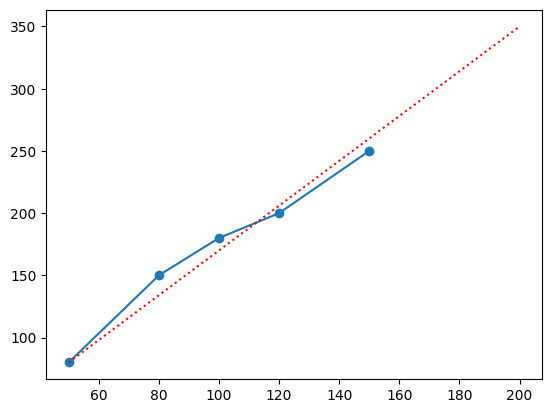

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# 这里的代码只是用于画图而已
x = np.array([50, 80, 100, 120, 150])
y = np.array([80, 150, 180, 200, 250])
x2 = np.array([50, 200])
y2 = np.array([80, 350])
plt.plot(x, y, marker='o')
plt.plot(x2, y2, linestyle='dotted', color='red')
plt.show()

> 蓝色的线是真实的数据,红色的线是我们找到的"最佳"直线.借助红色的线,我们就能预测出180平的房屋售价是多少.

### 代码演示

In [14]:
from sklearn.linear_model import LinearRegression

#1.准备数据
x_train = np.array([[50], [80], [100], [120], [150]])  # 特征数据
y_train = np.array([80, 150, 180, 200, 250])  # 标签
x_test = np.array([[180]])  # 预测数据
#2.模型训练
model = LinearRegression()
model.fit(x_train, y_train)
print("权重(斜率):", model.coef_)
print("偏置(截距):", model.intercept_)
print("预测180平房屋价格:", model.predict(x_test))

权重(斜率): [1.63793103]
偏置(截距): 8.206896551724128
预测180平房屋价格: [303.03448276]


## **多元线性回归**


多元线性回归,就是多个特征数据.

$ y = k_1x_1+k_2x_2+k_3x_3+ ... +k_nx_n+b $

或者

$y = w_0+w_1x_1+w_2x_2+w_3x_3+ ... +w_nx_n = w^Tx$

- $w_1$: 权重参数(斜率)，表示特征与目标之间的关联强度。
- $w_0$: 偏置参数(截距)，表示模型在数据中的偏移量。
- $x$: 特征值。
- $y$: 目标值。

为什么可以用 $y = w^Tx$ 来表示呢

为了把截距项也统一写进向量里,令 $x_0=1$,$w=(w_0,w_1,w_2,...,w_n)^T$,$x=(x_0,x_1,x_2,...,x_n)^T=(1,x_1,x_2,...,x_n)^T$,则:

$$w^Tx = \begin{pmatrix}
w_0\\
w_1\\
w_2\\
w_3\\
...\\
w_n\\
\end{pmatrix}^T * \begin{pmatrix}
1\\
x_1\\
x_2\\
x_3\\
...\\
x_n\\
\end{pmatrix} = w_0+w_1x_1+w_2x_2+w_3x_3+...+w_nx_n$$


> 举个例子:房子的价格不止受面积的影响,还有房子位置,房子朝向,房子楼层等等
> 数据:
>
>| 房子面积($m^2$) | 房子位置 | 房子朝向 | 房子楼层 | 房子价格(万元) |
>|-------------|----------|----------|----------|----------|
>| 50          | 1        | 1        | 1        | 80       |
>| 80          | 1        | 1        | 2        | 150      |
>| 100         | 1        | 1        | 3        | 180      |
>| 120         | 1        | 1        |4          | 200|
>
>$x$是表示特征的:
>- $x_1$:房子面积
>- $x_2$:房子位置
>- $x_3$:房子朝向
>- $x_4$:房子楼层
>
>$w$表示特征的权重:
>- $w_1$:房子面积的权重
>- $w_2$:房子位置的权重
>- $w_3$:房子朝向的权重
>- $w_4$:房子楼层的权重

## **损失函数**

我们需要一个标准来衡量直线的好坏,这就是**损失函数**


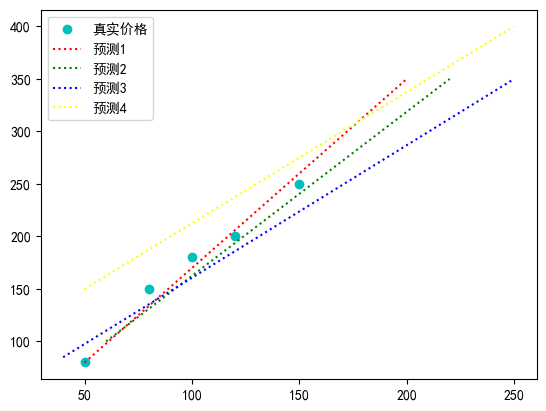

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# 这里的代码只是用于画图而已
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
x = np.array([50, 80, 100, 120, 150])
y = np.array([80, 150, 180, 200, 250])
x2 = np.array([50, 200])
y2 = np.array([80, 350])
plt.plot(x, y, 'o', color='c', label='真实价格')
plt.plot(x2, y2, linestyle='dotted', color='red', label='预测1')
plt.plot([60, 220], [100, 350], linestyle='dotted', color='green', label='预测2')
plt.plot([40, 250], [85, 350], linestyle='dotted', color='blue', label='预测3')
plt.plot([50, 250], [150, 400], linestyle='dotted', color='yellow', label='预测4')
plt.legend()
plt.show()

如上图所示,有四条线,哪条线最接近真实数据呢?那条线才是最好的呢?

**损失函数**: 也叫做成本函数,代价函数,目标函数.每个样本点 和 其预测值之间的关系,损失函数越小,说明预测值和样本点越接近

常用的损失函数是**均方误差(Mean-Square Error,MSE)**:

$$MSE = \frac{1}{n}\sum_{i=1}^{n}(\hat{y_i}-y_i)^2$$
- $n$是样本点的个数
- $y_i$是样本点对应的真实值
- $\hat{y_i}$是样本点对应的预测值

一般使用**正规方程法**和**梯度下降法**求解损失函数.

### **正规方程法**(了解)

列出数学方程求出精确解

**优点**:一步就可以求出精确解.

**缺点**:计算量非常大,不适合大数据集,$X^TX$的逆矩阵不存在时,无法求解.并且求解逆矩阵非常耗时.

#### **前置知识**

**复杂函数的求导**: 先对外函数求导,再对内函数求导
> $f(x) = (x^2+2x)^2$
>
> $f'(x) = 2(x^2+2x)^1(x^2+2x)' = 2(x^2+2x)(2x+2) = 4x^3+12x^2+8x$


**偏导**: 固定其他，只变一个,把其他变量都当作常数.比如对x求导,则可以将y看成常数项
>$ f(x,y) = (x - 2)^2 + (y - 3)^2$
>
> 对y求导: $f_y(x,y) = \frac{\partial f}{\partial y} = 2(y-3)$
>
> 对x求导: $f_x(x,y) = \frac{\partial f}{\partial x} = 2(x-2)$

**范数**:

**1范数**: 向量中各个元素的绝对值之和.

**2范数**: 就是向量的模长,向量中各个元素的平方之和,再开平方根.

> $X$为向量,$x^Tx$ 与$||X||^2_2$是一样的

#### **一元线性回归_损失函数_正规方程法_推演过程**

根据公式: $MSE = \frac{1}{n}\sum_{i=1}^{n}(\hat{y_i}-y_i)^2$

其中$\hat{y_i}$是预测值, $y_i$是真实值

所以$\hat{y_i}$可以表示为:
$\hat{y_i} = kx_i + b$

1. 求$k$的偏导:

① $f(k,b) = 0 =\frac{1}{n}\sum_{i=1}^{n}(kx_i+b-y_i)^2$


②$f_k(k,b) = 0 = \frac{\partial f}{\partial k} = \frac{1}{n}\sum_{i=1}^{n}(2(kx_i+b-y_i)(kx_i+b-y_i)')$

因为对$k$求偏导,其他变量都当作常数,所以$(kx_i+b-y_i)'$ 就只有$x_i$

③$0  = \frac{1}{n}\sum_{i=1}^{n}(2(kx_i+b-y_i)x_i)$

④$0 = \sum_{i=1}^{n}(kx_i^2+bx_i-x_iy_i)$

⑤$0 = k\sum_{i=1}^{n}x_i^2+b\sum_{i=1}^{n}x_i-\sum_{i=1}^{n}x_iy_i$

2. 求$b$的偏导:

⑥$f_b(k,b) = 0 = \frac{\partial f}{\partial b} = \frac{1}{n}\sum_{i=1}^{n}(2(kx_i+b-y_i)(kx_i+b-y_i)')$

因为对$b$求偏导,其他变量都当作常数,所以$(kx_i+b-y_i)'$ 就只有$1$

⑦$0 = \frac{1}{n}\sum_{i=1}^{n}(2(kx_i+b-y_i)*1))$

⑧$0 = k\sum_{i=1}^{n}x_i + nb - \sum_{i=1}^{n}y_i$


> | $x$房子面积($m^2$) | $y$房子价格(万元) |
> |----------------|-------------|
> | 50             | 80          |
> | 80             | 150         |
> | 100            | 180         |
> | 120            | 200         |
> | 150            | 250         |
> | 180            | ?           |
>
> 比如这个数据,我们可以使用推导的公式⑤和公式⑧得到:
>
> ⑤->$0 = k(50^2+80^2+100^2+120^2+150^2) + b(50+80+100+120+150) - (50*80+80*150+100*180+120*200+150*250)$
>
> ⑨ $0 = 55800k + 500b - 95500$
>
> ⑧->$0 = k(50+80+100+120+150) + 5b - (80+150+180+200+250)$
>
> ⑩ $0 = 500k + 5b - 860$
>
> 联立⑨⑩,得到:
>
> $k = \frac{95}{58} \approx 1.6379$
>
> $b = \frac{238}{29} \approx 8.2069$
>
> 所以 $y = kx+b$ -> $y = 1.6379x+8.2069$
>
> 预测180平方米的房子价格: $y = 1.6379*180+8.2069= 303.0289$
>
> 303.0289与代码输出的303.03448276很接近



#### **多元线性回归_损失函数_正规方程法_推演过程**

已知多元线性回归方程为:

$w^Tx = \begin{pmatrix}
w_0\\
w_1\\
w_2\\
w_3\\
...\\
w_n\\
\end{pmatrix}^T * \begin{pmatrix}
1\\
x_1\\
x_2\\
x_3\\
...\\
x_n\\
\end{pmatrix} = w_0+w_1x_1+w_2x_2+w_3x_3+...+w_nx_n$

所以可以得知第一个样本的预测值为:

$ w^Tx_1 =  w_0+w_1x_{1,1}+w_2x_{1,2}+w_3x_{1,3}+...+w_dx_{1,d}$

- $d$: 特征个数

第一个样本的误差平方为:

$ (\hat{y_1} - y_1)^2 = (w_0+w_1x_{1,1}+w_2x_{1,2}+w_3x_{1,3}+...+w_dx_{1,d} - y_1)^2 = (\sum_{j=1}^{d}(w_jx_{1,j}+w_0)-y_1)^2$

n个样本的损失,就是把所有样本的误差平方求和:

$j(w) = \sum_{i=1}^{n}((\sum_{j=1}^{d}(w_jx_{i,j}+w_0)-y_i)^2)$

**注意:此时所有样本的特征$x_{i,j}$可以组成一个矩阵$X$,$y_i$可以组成一个向量$y$**

用$X$表示特征矩阵(每行是一个样本,第一列全为1,对应偏置项$w_0$),用$y$表示标签向量,上面的损失函数可以写成:

$ j(w) = (Xw-y)^T(Xw-y)$

针对$w$求偏导,并令其等于0:

$\frac{\partial j}{\partial w} = 2X^T(Xw-y) = 0$

$ X^TXw - X^Ty = 0$

$  X^TXw = X^Ty$

两边同时左乘$(X^TX)^{-1}$:

$(X^TX)^{-1}(X^TX)w = (X^TX)^{-1}X^Ty$

即可得到:

$$w = (X^TX)^{-1}X^Ty$$


> 举个例子:房子的价格不止受面积的影响,还有房子位置,房子朝向,房子楼层等等
> 数据:
>
>| $x_0$ | $x_1$房子面积($m^2$) | $x_2$房子位置 | $x_3$房子朝向 | $x_4$房子楼层 | $y$房子价格(万元) |
>|-------|------------------|-----------|-----------|-----------|-------------|
>| 1     | 50               | 1         | 0         | 1         | 80          |
>| 1     | 80               | 1         | 1         | 2         | 150         |
>| 1     | 100              | 2         | 0         | 3         | 180         |
>| 1     | 120              | 2         | 1         | 4         | 200         |
>| 1     | 150              | 3         | 2         | 5         | 250         |
>
>注意:这里用了5个样本、5个参数(含截距项$w_0$),并且各特征列线性无关,保证$X^TX$可逆.
>
>其中:
>
>$X = \begin{pmatrix}
1&50&1&0&1\\
1&80&1&1&2\\
1&100&2&0&3\\
1&120&2&1&4\\
1&150&3&2&5\\
\end{pmatrix}$
>
> $y = \begin{pmatrix}
80\\
150\\
180\\
200\\
250\\
\end{pmatrix}$
>
> 代入公式: $w = (X^TX)^{-1}X^Ty$
>
> $w = \begin{pmatrix}
-85\\
5\\
-20\\
-15\\
-65
\end{pmatrix}$
>
> 即: $y = -85 + 5x_1 - 20x_2 - 15x_3 - 65x_4$
>
> 验证第一个样本: $-85 + 5\times50 - 20\times1 - 15\times0 - 65\times1 = 80$ ✓


#### **正规方程_波士顿房价预测**


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_squared_error, root_mean_squared_error,mean_absolute_error
import numpy as np
import pandas as pd
# 1. 加载数据
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]]) # 水平合并特征和目标变量
target = raw_df.values[1::2, 2]
# print(data.shape)
# print(target.shape)
# print("特征数据:",data[:5])
# print("标签数据:",target[:5])
# 2.特征预处理
x_train, x_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=42)
# 3.特征工程
# 3.1创建标准化对象
scaler = StandardScaler()
# 3.2对训练集进行标准化
x_train_scaled = scaler.fit_transform(x_train)
# 3.3对测试数据进行转换
x_test_scaled = scaler.transform(x_test)
#4.模型训练
#4.1创建线性回归模型对象
model = LinearRegression(fit_intercept=True)#fit_intercept:是否计算截距项(bias,偏置)
#4.2对训练数据进行拟合(训练)
model.fit(x_train_scaled, y_train)
# 4.3查看模型参数
print("模型参数(w):",model.coef_)
print("截距项(bias,偏置):",model.intercept_)
# 5.模型预测
y_pred = model.predict(x_test_scaled)
print("预测值:",y_pred)
#6.模型评估
mse = mean_squared_error(y_test, y_pred)
print("均方误差(MSE):",mean_squared_error(y_test, y_pred))
print("均方根误差(RMSE):",root_mean_squared_error(y_test, y_pred))
print("平均绝对误差(MAE):",mean_absolute_error(y_test, y_pred))


特征数据: [[6.3200e-03 1.8000e+01 2.3100e+00 0.0000e+00 5.3800e-01 6.5750e+00
  6.5200e+01 4.0900e+00 1.0000e+00 2.9600e+02 1.5300e+01 3.9690e+02
  4.9800e+00]
 [2.7310e-02 0.0000e+00 7.0700e+00 0.0000e+00 4.6900e-01 6.4210e+00
  7.8900e+01 4.9671e+00 2.0000e+00 2.4200e+02 1.7800e+01 3.9690e+02
  9.1400e+00]
 [2.7290e-02 0.0000e+00 7.0700e+00 0.0000e+00 4.6900e-01 7.1850e+00
  6.1100e+01 4.9671e+00 2.0000e+00 2.4200e+02 1.7800e+01 3.9283e+02
  4.0300e+00]
 [3.2370e-02 0.0000e+00 2.1800e+00 0.0000e+00 4.5800e-01 6.9980e+00
  4.5800e+01 6.0622e+00 3.0000e+00 2.2200e+02 1.8700e+01 3.9463e+02
  2.9400e+00]
 [6.9050e-02 0.0000e+00 2.1800e+00 0.0000e+00 4.5800e-01 7.1470e+00
  5.4200e+01 6.0622e+00 3.0000e+00 2.2200e+02 1.8700e+01 3.9690e+02
  5.3300e+00]]
标签数据: [24.  21.6 34.7 33.4 36.2]
模型参数(w): [-1.00213533  0.69626862  0.27806485  0.7187384  -2.0223194   3.14523956
 -0.17604788 -3.0819076   2.25140666 -1.76701378 -2.03775151  1.12956831
 -3.61165842]
截距项(bias,偏置): 22.796534653465375
预测值: [28

一般来说,**RMSE≥MAE**恒成立;当误差数值较大(均方误差>1)时,才有**MSE>RMSE**

### **梯度下降**

**单变量**函数中,梯度就是某一点切线的斜率(某一点的导数),其方向为函数值增长最快的方向.

**多变量**函数中,梯度就是某一点的偏导数,偏导数分量的向量方向.

公式: **当前点-学习率*损失函数的偏导数**

$$θ_{i+1} = θ_i - \alpha \frac{\partial }{\partial θ_i}J(θ)$$

- $θ_i$:当前点
- $θ_{i+1}$:下一个点
- $\alpha$:学习率(步长),不能太大,也不能太小,一般为0.001~0.01
- $J(θ)$:损失函数

#### **代码演示**

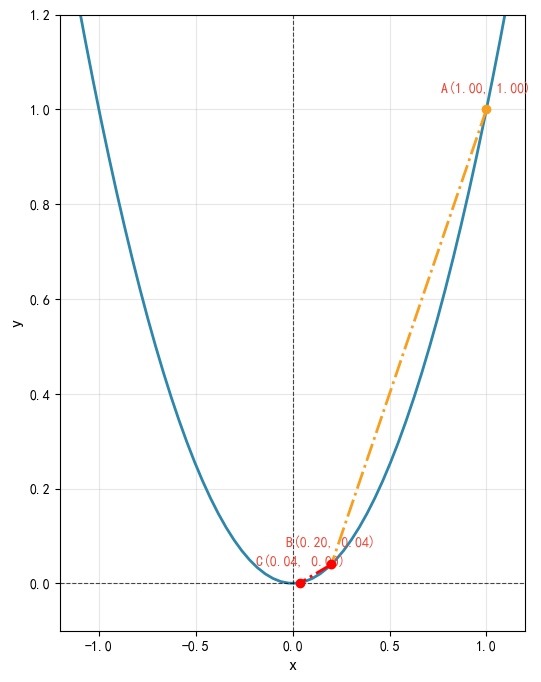

In [63]:
# 此代码只用于绘图
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
# ===================== 1. 定义一元二次方程参数 =====================
a = 1
# b = -2
# c = -3
b = 0
c = 0

# ===================== 2. 生成抛物线基础数据 =====================
x = np.linspace(-2, 2, 100)
y = a * x ** 2 + b * x + c

# ===================== 3. 定义需要标注的自定义点 =====================
# 方法：先指定要标注的x坐标，计算对应的y值（也可直接写坐标）
# 示例：标注x=1、x=0.2、x=0.04这三个点
x_points = [1, 0.2, 0.04]
y_points = [a * x ** 2 + b * x + c for x in x_points]  # 自动计算y值
labels = ['A', 'B', 'C']
# 也可直接写坐标：points = [(1, 1), (0.2, 0.04), (0.04, 0.0016)]

# ===================== 4. 定义需要连线的两个点（从自定义点中选） =====================
# 示例：连接x=1（点A）和x=0.2（点B），再连接x=0.2（点B）和x=0.04（点C）
x_line_1 = [1, 0.2]
y_line_1 = [a * x ** 2 + b * x + c for x in x_line_1]
x_line_2 = [0.2, 0.04]
y_line_2 = [a * x ** 2 + b * x + c for x in x_line_2]

# ===================== 5. 绘制基础图表 =====================
plt.figure(figsize=(6, 8))
plt.plot(x, y, color='#2E86AB', linewidth=2, )

# 绘制坐标轴
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
# 循环给每个点标注字母（可选择仅字母 / 字母+坐标）
for i, (x_p, y_p) in enumerate(zip(x_points, y_points)):
    plt.annotate(f'{labels[i]}({x_p:.2f}, {y_p:.2f})',
                 (x_p, y_p),
                 textcoords="offset points",
                 xytext=(0, 12),
                 ha='center',
                 fontsize=10,
                 color='#E94B3C')
plt.plot(x_line_1, y_line_1, color='#F79F1F', linestyle='-.', marker='o', linewidth=2, zorder=4)
plt.plot(x_line_2, y_line_2, color='red', linestyle='-.', marker='o', linewidth=2, zorder=4)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)

plt.xlim(-1.2, 1.2)  # x轴范围：左边界-1.2，右边界1.2
plt.ylim(-0.1, 1.2)  # y轴范围：下边界-0.1，上边界1.2
# plt.legend(loc='best')
plt.grid(True, alpha=0.3)

plt.show()

> 如上图所示,A为起始点(当前点),B为下一个点:
>
> 假设$J(θ)$=$θ^2$, 起点为θ=1,学习率α=0.4
>
>  ①:$θ_{i+1} = θ_i - \alpha \frac{\partial }{\partial θ_i}J(θ)$
>
>步骤1: 计算当前点-学习率*损失函数的偏导数
>
> $J(θ)' = \frac{\partial }{\partial θ_i}J(θ) = 2θ$
>
>步骤二: 计算下一个点
>
> $θ_{i+1} = θ_i - \alpha \frac{\partial }{\partial θ_i}J(θ) = 1 - 0.4*2*1 = 0.2$
>
> 步骤三:再次计算下一个点,一直循环,无限接近极值或满足条件(最优解)
>
> $θ_{i+1} = 0.2 - 0.4*2*0.2 = 0.04$

#### **梯度下降分类**

1.**全梯度下降算法**FGD(Full Gradient Descent): 每次迭代时,使用**全部样本**的梯度值.

**注意**: 全梯度下降算法的计算量较大,在样本数量较多时,训练速度较慢,不建议使用

$ θ_{i+1} = θ_i - \alpha \sum_{j=0}^{m}(h_θ(x_0^{(j)},x_1^{(j)},x_2^{(j)},...,x_n^{(j)}) - y_j)x_i^{(j)}$

- $x_i^{(j)}$: 为第$j$个样本的第$i$个特征值




2.**随机梯度下降算法**SGD(Stochastic Gradient Descent): 每次迭代时,使用**随机选择一个样本**的梯度值.

**注意**: 随机梯度下降算法的计算量较小,简单,高效,但是不稳定,若遇上噪声则容易陷入局部最优解.

$ θ_{i+1} = θ_i - \alpha (h_θ(x_0^{(j)},x_1^{(j)},x_2^{(j)},...,x_n^{(j)}) - y_j)x_i^{(j)}$ 

- $x_i^{(j)}$: 为第$j$个样本的第$i$个特征值



3.**随机平均梯度下降算法**SAG(Stochastic Average Gradient Descent): 每次迭代时,随机选择**一个样本的梯度值**与**以往样本的梯度值的平均值**

**注意**: 初期表现不佳,优化速度较慢,但是在后期表现良好,收敛速度快.



$ θ_{i+1} = θ_i - \alpha \frac{1}{m} \sum_{j=0}^{m}(h_θ(x_0^{(j)},x_1^{(j)},x_2^{(j)},...,x_n^{(j)}) - y_j)x_i^{(j)}$


举例:假设随机选择的一个样本为D,计算其梯度值并存储到列表[D]中,然后计算列表中的梯度均值,更新模型参数;再随机选择另一个样本G,计算G的梯度值,并将其存储到列表中,此时列表中有[D,G]两个样本的梯度值,计算它们的均值,更新模型参数.以此类推,直到迭代次数达到预设值.

4.**小批量梯度下降算法**MBGD(Minibatch Gradient Descent): 每次迭代时,随机选择**多个样本的梯度值**.从m个样本中选择x个样本进行迭代(1<x<m).

$ θ_{i+1} = θ_i - \alpha \sum_{j=t}^{t+x-1}(h_θ(x_0^{(j)},x_1^{(j)},x_2^{(j)},...,x_n^{(j)}) - y_j)x_i^{(j)}$



若batch_size = m,则退化为批量梯度下降算法.若batch_size = 1,则退化为随机梯度下降算法.


#### **梯度下降_波士顿房价预测**

In [9]:
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_squared_error, root_mean_squared_error,mean_absolute_error
import numpy as np
import pandas as pd
# 1. 加载数据
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]]) # 水平合并特征和目标变量
target = raw_df.values[1::2, 2]
# print(data.shape)
# print(target.shape)
# print("特征数据:",data[:5])
# print("标签数据:",target[:5])
# 2.特征预处理
x_train, x_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=42)
# 3.特征工程
# 3.1创建标准化对象
scaler = StandardScaler()
# 3.2对训练集进行标准化
x_train_scaled = scaler.fit_transform(x_train)
# 3.3对测试数据进行转换
x_test_scaled = scaler.transform(x_test)
#4.模型训练
#4.1创建线性回归模型对象
#fit_intercept:是否计算截距项(bias,偏置),learning_rate:学习率,constant:固定学习率,eta0:学习率的初始值
model = SGDRegressor(fit_intercept=True,learning_rate='constant',eta0=0.01)
#4.2对训练数据进行拟合(训练)
model.fit(x_train_scaled, y_train)
# 4.3查看模型参数
print("模型参数(w):",model.coef_)
print("截距项(bias,偏置):",model.intercept_)
# 5.模型预测
y_pred = model.predict(x_test_scaled)
print("预测值:",y_pred)
#6.模型评估
mse = mean_squared_error(y_test, y_pred)
print("均方误差(MSE):",mean_squared_error(y_test, y_pred))
print("均方根误差(RMSE):",root_mean_squared_error(y_test, y_pred))
print("平均绝对误差(MAE):",mean_absolute_error(y_test, y_pred))

模型参数(w): [-1.45772367  0.62689898  0.41379804  0.9928888  -1.90726221  3.24214045
 -0.29469046 -3.19821879  2.22628243 -1.64541044 -2.02487546  0.70651308
 -3.95197869]
截距项(bias,偏置): [22.76414811]
预测值: [28.83861076 37.21753502 15.06234178 25.25811486 18.68677544 23.19011334
 17.09885987 14.06177662 22.92591719 20.44740338 25.47874238 17.9059165
 -8.09132294 21.6489536  18.85321272 26.54007085 20.50584861  4.45432275
 40.46282899 17.17730255 27.28079168 29.98177884 10.56308187 24.324524
 18.03180865 15.44539187 22.83281044 15.99026804 22.89736065 19.00521959
 21.86470461 25.2320453  25.36809823 17.97397724 16.58781    17.60667445
 31.4025499  19.87419849 24.54360083 24.85125901 13.35262405 32.03146642
 42.67917267 16.79995814 27.16241667 16.6877346  13.51934902 26.15866566
 20.09099264 29.95411875 20.72816595 34.34179991 15.36232713 26.41243658
 39.88729757 22.82888556 18.71696707 32.66307037 24.83988497 11.88497813
 22.31928695 30.10250471 31.95855836 16.22443143 19.90773634 16.7451332

## **正则化_解决过拟合问题**


**过拟合出现的原因**:
1. 模型复杂度过高,例如:原始特征过多,存在一些冗余特征,模型尝试去兼顾各个训练样本点.
2. 训练数据量不足

**解决办法**:
1. 重新清洗数据.
2. 增加训练数据量.
3. 正则化.
4. 减少特征维度,防止维数灾难.

### **正则化**





**正则化**:在模型训练时,数据中有些特征影响模型的复杂度,或者某个特征的异常值较多,所以要尽量减少这个特征的影响(甚至删除这个特征的影响),这就是正则化.主要有L1正则化和L2正则化.

#### **L1(Lasso)正则化**

$$J(w) = MSE(w) + \alpha \sum_{i=1}^n |w_i|$$

- $\alpha$:正则化参数(惩罚系数),控制正则化的强度,该值越大,正则化的效果越强,即对特征权重的惩罚越大.
- $MSE(w)$:均方误差.
- $w_i$:模型的第i个系数(权重).
- $n$:特征的数量.

L1正则化会使模型的权重(w)**趋近于0**,甚至**变成0**,使得某些特征失效,从而实现特征选择的效果.

##### **代码演示**

d:\workspaces\pycharm\MachineLearning\.venv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.586e+01, tolerance: 5.269e-02
  model = cd_fast.enet_coordinate_descent(


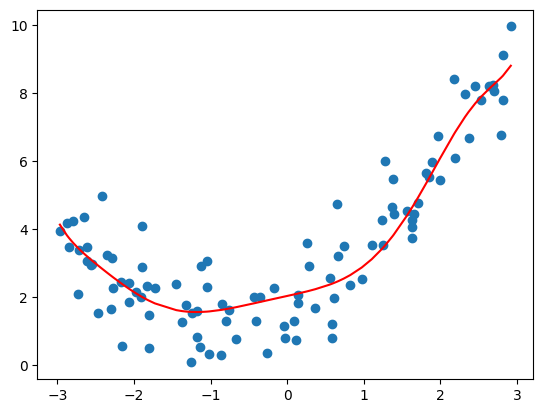

In [16]:
from sklearn.linear_model import Lasso
import matplotlib.pyplot as plt

# 生成随机数据
np.random.seed(42)
# 随机生成x轴,-3到3之间的100个点,模拟 特征
x = np.random.uniform(-3, 3, size=100)# 最小值为-3,最大值为3,生成100个点
# 模拟目标变量y,0.5x^2+x+2+噪声
y = 0.5 * x **2+x+2+np.random.normal(0, 1, size=100)
# 转换为列向量, sklearn要求输入特征为二维数组
X = x.reshape(-1, 1)
# 因为当前的特征只有一列,过于简单,为了演示过拟合,添加一些多项式特征
X = np.hstack([X, X**2, X**3, X**4, X**5, X**6, X**7, X**8, X**9, X**10])
#创建模型对象
estimator = Lasso(alpha=0.1) # alpha为正则化参数(惩罚系数),控制正则化的强度
estimator.fit(X, y)
# 预测
y_pred = estimator.predict(X)
# 绘图
plt.scatter(x, y)# 绘制原始数据点
plt.plot(np.sort(x), y_pred[np.argsort(x)], color='red') # 绘制预测线

plt.show()



#### **L2(Ridge)正则化**

$$J(w) = MSE(w) + \alpha \sum_{i=1}^n w_i^2$$

- $\alpha$:正则化参数(惩罚系数),控制正则化的强度,该值越大,正则化的效果越强,即对特征权重的惩罚越大.
- $MSE(w)$:均方误差.
- $w_i$:模型的第i个系数(权重).
- $n$:特征的数量.

L2正则化会使模型的权重(w)**趋近于0**,但**不会变成0**,从而保留所有特征的影响.


##### **代码演示**

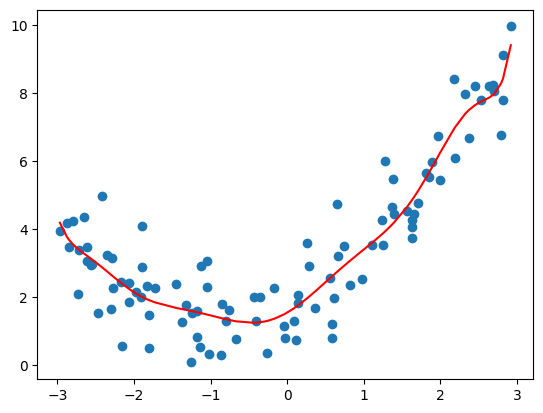

In [17]:
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt

# 生成随机数据
np.random.seed(42)
# 随机生成x轴,-3到3之间的100个点,模拟 特征
x = np.random.uniform(-3, 3, size=100)# 最小值为-3,最大值为3,生成100个点
# 模拟目标变量y,0.5x^2+x+2+噪声
y = 0.5 * x **2+x+2+np.random.normal(0, 1, size=100)
# 转换为列向量, sklearn要求输入特征为二维数组
X = x.reshape(-1, 1)
# 因为当前的特征只有一列,过于简单,为了演示过拟合,添加一些多项式特征
X = np.hstack([X, X**2, X**3, X**4, X**5, X**6, X**7, X**8, X**9, X**10])
#创建模型对象
estimator = Ridge(alpha=0.1) # alpha为正则化参数(惩罚系数),控制正则化的强度
estimator.fit(X, y)
# 预测
y_pred = estimator.predict(X)
# 绘图
plt.scatter(x, y)# 绘制原始数据点
plt.plot(np.sort(x), y_pred[np.argsort(x)], color='red') # 绘制预测线

plt.show()